# Probability for ML, Deep Learning & Modern AI

Probability is how models express **uncertainty**. Every prediction, every loss function,  
every generative model — all grounded in probability theory.

```python
# A classifier doesn't say: "This is a cat"
# It says: P(cat | image) = 0.95   ← 95% confident
```

| Section | Topic | Used In |
|---|---|---|
| 1 | Probability Basics (rules) | Every probabilistic model |
| 2 | Random Variables | Representing uncertain data |
| 3 | Distributions — Gaussian | Linear regression, VAEs, diffusion |
| 4 | Distributions — Bernoulli, Categorical | Classification, language models |
| 5 | Bayes' Theorem | Naive Bayes, Bayesian inference |
| 6 | MLE — Maximum Likelihood | How parameters are learned |
| 7 | Naive Bayes Classifier | Text classification |
| 8 | Entropy, KL Divergence & Cross-Entropy | Loss functions, VAEs, diffusion |
| 9 | Probability in Transformers | Softmax, temperature, sampling |
| 10 | Probability in Generative AI | VAE ELBO, diffusion score matching |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, bernoulli

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## 1. Probability Basics

Probability is a number between 0 (impossible) and 1 (certain).

### Three rules everything builds on:
| Rule | Formula | Meaning |
|---|---|---|
| **Sum rule** | `P(A) = Σ P(A, B)` | Add over all values of B |
| **Product rule** | `P(A, B) = P(A) · P(B\|A)` | Joint = marginal × conditional |
| **Complement** | `P(not A) = 1 - P(A)` | All probabilities sum to 1 |

### Three types of probability:
```
P(A, B)   Joint        — A AND B both happen
P(A)      Marginal     — A happens regardless of B
P(A | B)  Conditional  — A happens GIVEN that B already happened
```

=== Probability Types ===
P(spam)            = 0.5    ← marginal
P(FREE)            = 0.4    ← marginal
P(spam AND FREE)   = 0.3   ← joint
P(FREE | spam)     = 0.6   ← conditional

Product rule:  P(A,B) = P(B|A) * P(A)
  0.6 * 0.5 = 0.3  ==  P(spam AND FREE)=0.3  ✓


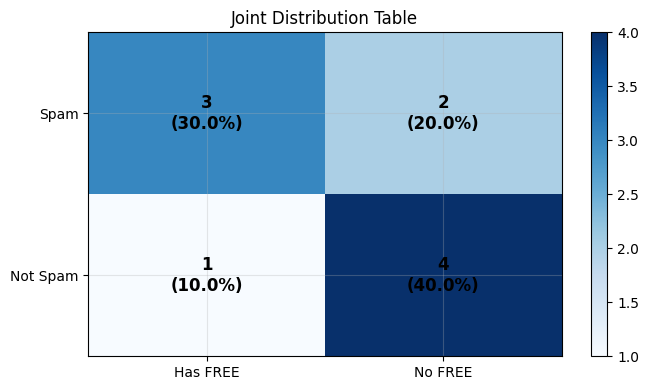

In [2]:
# Spam email dataset: (spam=1/0, contains_word_FREE=1/0)
emails = [
    (1, 1), (1, 1), (1, 0), (1, 1), (1, 0),  # spam
    (0, 0), (0, 0), (0, 1), (0, 0), (0, 0),  # not spam
]
n = len(emails)

spam      = [e for e in emails if e[0] == 1]
has_free  = [e for e in emails if e[1] == 1]
spam_free = [e for e in emails if e[0] == 1 and e[1] == 1]

P_spam          = len(spam) / n
P_free          = len(has_free) / n
P_spam_and_free = len(spam_free) / n
P_free_given_spam = len(spam_free) / len(spam)

print("=== Probability Types ===")
print(f"P(spam)            = {P_spam}    ← marginal")
print(f"P(FREE)            = {P_free}    ← marginal")
print(f"P(spam AND FREE)   = {P_spam_and_free}   ← joint")
print(f"P(FREE | spam)     = {P_free_given_spam}   ← conditional")
print()
print("Product rule:  P(A,B) = P(B|A) * P(A)")
print(f"  {P_free_given_spam} * {P_spam} = {P_free_given_spam * P_spam}  ==  P(spam AND FREE)={P_spam_and_free}  ✓")

# Visualize as a grid
fig, ax = plt.subplots(figsize=(7, 4))
table_data = np.array([[3, 2], [1, 4]])  # spam/not-spam × free/not-free
im = ax.imshow(table_data, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{table_data[i,j]}\n({table_data[i,j]/n:.1%})',
                ha='center', va='center', fontsize=12, fontweight='bold')
ax.set_xticks([0,1])
ax.set_xticklabels(['Has FREE', 'No FREE'])
ax.set_yticks([0,1])
ax.set_yticklabels(['Spam', 'Not Spam'])
ax.set_title('Joint Distribution Table')
plt.colorbar(im)
plt.tight_layout()
plt.show()

---
## 2. Random Variables

A **random variable** is a quantity whose value is uncertain — it can take different values with different probabilities.

| Type | Values | Example in ML |
|---|---|---|
| **Discrete** | Countable set | Class label (0,1,2...), word ID |
| **Continuous** | Any real number | Height, pixel value, weight |

### Key statistics:
- **Mean (μ):** Expected value, center of distribution
- **Variance (σ²):** Average squared distance from mean
- **Standard deviation (σ):** Spread in the same units as data

=== Discrete RV: Coin Flip ===
P(heads) estimate: 0.510  (true: 0.5)

=== Continuous RV: House Prices ===
Mean:     $302,008
Std Dev:  $50,040
Variance: $2,503,960,261


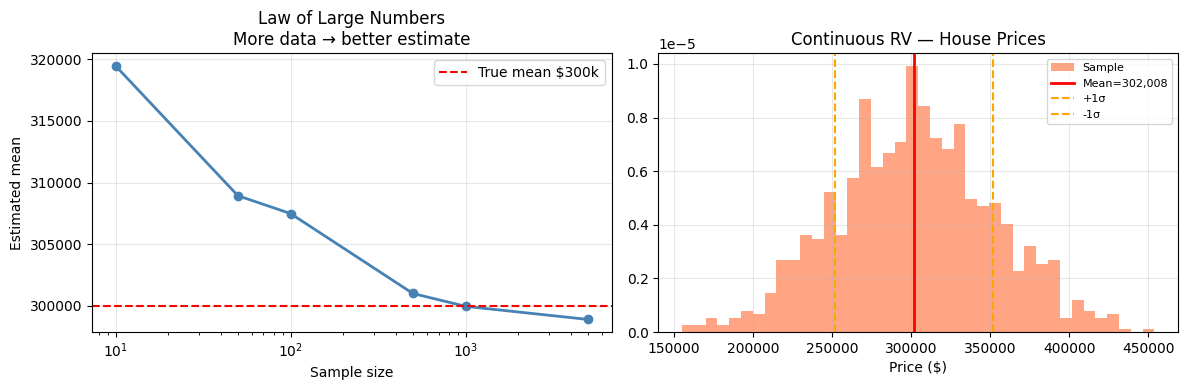

In [3]:
# Discrete: coin flip simulation
flips = np.random.randint(0, 2, size=1000)  # 0=tails, 1=heads
print("=== Discrete RV: Coin Flip ===")
print(f"P(heads) estimate: {flips.mean():.3f}  (true: 0.5)")

# Continuous: house prices
prices = np.random.normal(300_000, 50_000, 1000)
print("\n=== Continuous RV: House Prices ===")
print(f"Mean:     ${prices.mean():,.0f}")
print(f"Std Dev:  ${prices.std():,.0f}")
print(f"Variance: ${prices.var():,.0f}")

# Law of Large Numbers — more samples → closer to true mean
sample_sizes = [10, 50, 100, 500, 1000, 5000]
estimates = [np.random.normal(300_000, 50_000, n).mean() for n in sample_sizes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(sample_sizes, estimates, 'o-', color='steelblue', lw=2)
axes[0].axhline(300_000, color='red', linestyle='--', label='True mean $300k')
axes[0].set_title('Law of Large Numbers\nMore data → better estimate')
axes[0].set_xlabel('Sample size')
axes[0].set_ylabel('Estimated mean')
axes[0].legend()

axes[1].hist(prices, bins=40, density=True, alpha=0.7, color='coral', label='Sample')
axes[1].axvline(prices.mean(), color='red', lw=2, label=f'Mean={prices.mean():,.0f}')
axes[1].axvline(prices.mean()+prices.std(), color='orange', lw=1.5, linestyle='--', label='+1σ')
axes[1].axvline(prices.mean()-prices.std(), color='orange', lw=1.5, linestyle='--', label='-1σ')
axes[1].set_title('Continuous RV — House Prices')
axes[1].set_xlabel('Price ($)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. Gaussian Distribution (Normal Distribution)

The most important distribution in ML. Appears naturally due to the **Central Limit Theorem**:  
*The average of many independent random variables tends to be normally distributed.*

$$\mathcal{N}(x; \mu, \sigma^2) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**68-95-99.7 rule:**
- 68% of data falls within μ ± 1σ
- 95% within μ ± 2σ
- 99.7% within μ ± 3σ

**Used in:** Linear regression (noise assumption), Gaussian Naive Bayes, VAEs (latent space), diffusion models.

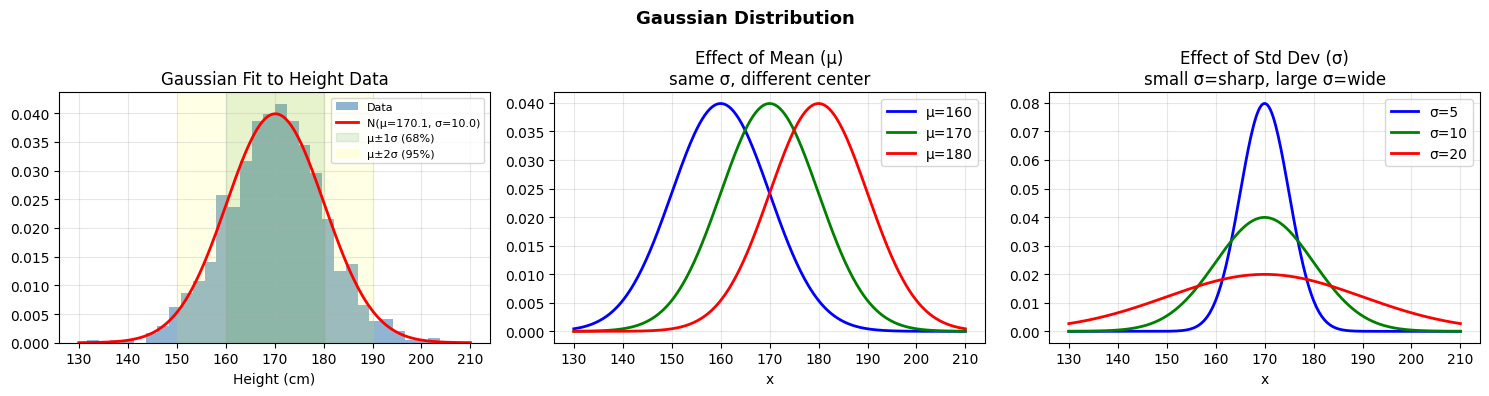

68% of heights fall between: 160.1 – 180.1 cm
95% of heights fall between: 150.1 – 190.1 cm


In [4]:
heights = np.random.normal(170, 10, 1000)
mu, std = norm.fit(heights)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fitted distribution
x = np.linspace(130, 210, 300)
axes[0].hist(heights, bins=30, density=True, alpha=0.6, color='steelblue', label='Data')
axes[0].plot(x, norm.pdf(x, mu, std), 'r-', lw=2, label=f'N(μ={mu:.1f}, σ={std:.1f})')
for i, (sigma, label) in enumerate([(1,'68%'),(2,'95%')]):
    axes[0].axvspan(mu-sigma*std, mu+sigma*std, alpha=0.1, color=['green','yellow'][i], label=f'μ±{sigma}σ ({label})')
axes[0].set_title('Gaussian Fit to Height Data')
axes[0].set_xlabel('Height (cm)')
axes[0].legend(fontsize=8)

# Effect of changing mean
for m, color in [(160,'blue'),(170,'green'),(180,'red')]:
    axes[1].plot(x, norm.pdf(x, m, 10), lw=2, color=color, label=f'μ={m}')
axes[1].set_title('Effect of Mean (μ)\nsame σ, different center')
axes[1].set_xlabel('x')
axes[1].legend()

# Effect of changing std
for s, color in [(5,'blue'),(10,'green'),(20,'red')]:
    axes[2].plot(x, norm.pdf(x, 170, s), lw=2, color=color, label=f'σ={s}')
axes[2].set_title('Effect of Std Dev (σ)\nsmall σ=sharp, large σ=wide')
axes[2].set_xlabel('x')
axes[2].legend()

plt.suptitle('Gaussian Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"68% of heights fall between: {mu-std:.1f} – {mu+std:.1f} cm")
print(f"95% of heights fall between: {mu-2*std:.1f} – {mu+2*std:.1f} cm")

---
## 4. Bernoulli & Categorical Distributions

### Bernoulli — Binary outcome (0 or 1)
$$P(X=x) = p^x(1-p)^{1-x}$$

Used in: **Binary classification** (logistic regression output), spam/not-spam.

### Categorical — Multiple classes
Generalization of Bernoulli to K classes.  
$$P(X=k) = p_k, \quad \sum_k p_k = 1$$

Used in: **Multi-class classification** (softmax output), language models (next token prediction).

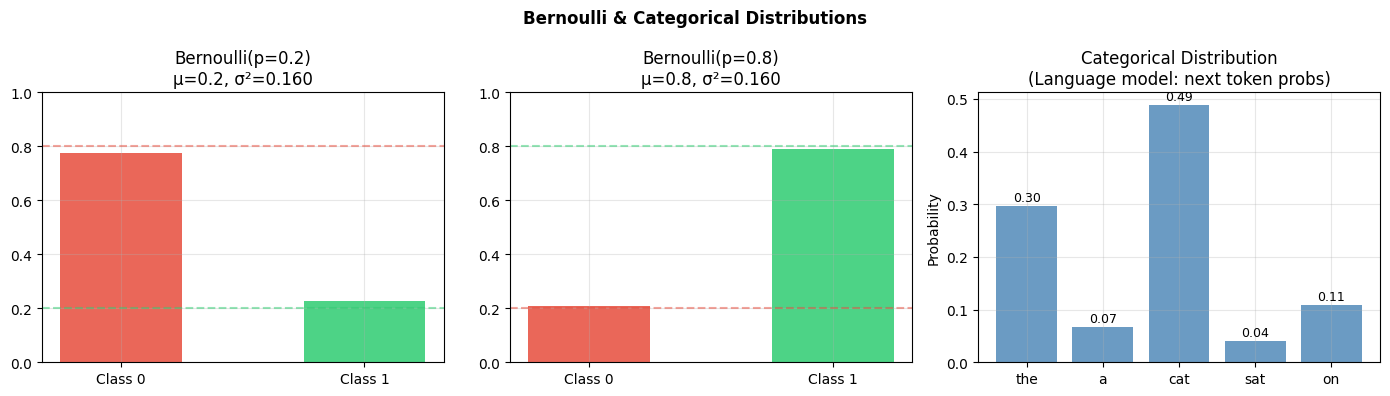

In logistic regression: output is P(y=1|x) — a Bernoulli probability
In language models:     output is P(token|context) — a Categorical distribution

Next-token probabilities: {'the': np.float64(0.296), 'a': np.float64(0.066), 'cat': np.float64(0.489), 'sat': np.float64(0.04), 'on': np.float64(0.109)}


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bernoulli at different p values
for ax, p in zip(axes[:2], [0.2, 0.8]):
    samples = bernoulli.rvs(p, size=500)
    counts = [np.mean(samples == 0), np.mean(samples == 1)]
    bars = ax.bar([0, 1], counts, color=['#e74c3c', '#2ecc71'], alpha=0.85, width=0.5)
    ax.axhline(1-p, color='#e74c3c', linestyle='--', alpha=0.5)
    ax.axhline(p, color='#2ecc71', linestyle='--', alpha=0.5)
    ax.set_title(f'Bernoulli(p={p})\nμ={p}, σ²={p*(1-p):.3f}')
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_ylim(0, 1)

# Categorical — language model next token
tokens = ['the', 'a', 'cat', 'sat', 'on']
# Softmax of logits
logits = np.array([2.5, 1.0, 3.0, 0.5, 1.5])
probs = np.exp(logits) / np.exp(logits).sum()

axes[2].bar(tokens, probs, color='steelblue', alpha=0.8)
axes[2].set_title('Categorical Distribution\n(Language model: next token probs)')
axes[2].set_ylabel('Probability')
for i, (t, p) in enumerate(zip(tokens, probs)):
    axes[2].text(i, p+0.01, f'{p:.2f}', ha='center', fontsize=9)

plt.suptitle('Bernoulli & Categorical Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("In logistic regression: output is P(y=1|x) — a Bernoulli probability")
print("In language models:     output is P(token|context) — a Categorical distribution")
print(f"\nNext-token probabilities: {dict(zip(tokens, probs.round(3)))}")

---
## 5. Bayes' Theorem

The most important equation in probabilistic ML:

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

| Term | Name | Meaning |
|---|---|---|
| `P(A)` | **Prior** | Belief *before* seeing data |
| `P(B\|A)` | **Likelihood** | How probable is the data if A is true? |
| `P(B)` | **Evidence** | Total probability of B (normalizer) |
| `P(A\|B)` | **Posterior** | Updated belief *after* seeing data |

> **Learning = updating priors with evidence to get posteriors.**

=== Medical Test — Bayes' Theorem ===
Prior P(disease)               = 1%
Test sensitivity               = 99%
False positive rate            = 5%
P(positive)                    = 0.0594

>>> P(disease | positive test) = 16.7% <<<

Surprising result: Even with a 99% accurate test, only ~17% of positives
actually have the disease — because the disease is so rare (1% prior).
This is the base rate fallacy. Priors matter enormously!


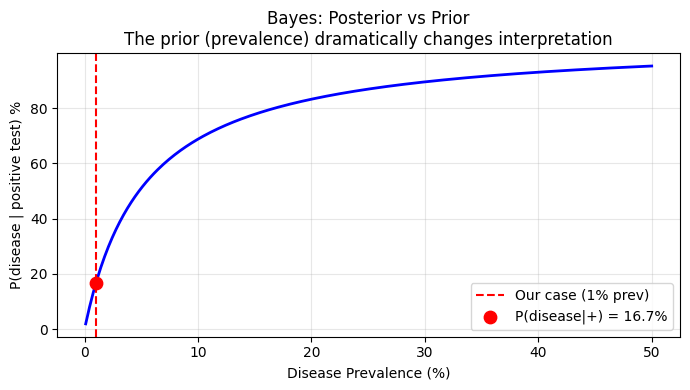

In [6]:
# Classic example: Medical test
# 1% of population has a disease
# Test sensitivity: P(positive | disease) = 99%
# False positive rate: P(positive | no disease) = 5%

P_disease    = 0.01
P_pos_given_disease    = 0.99
P_pos_given_no_disease = 0.05

# Law of total probability: P(positive)
P_positive = P_pos_given_disease * P_disease + P_pos_given_no_disease * (1 - P_disease)

# Bayes: P(disease | positive test)
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_positive

print("=== Medical Test — Bayes' Theorem ===")
print(f"Prior P(disease)               = {P_disease:.0%}")
print(f"Test sensitivity               = {P_pos_given_disease:.0%}")
print(f"False positive rate            = {P_pos_given_no_disease:.0%}")
print(f"P(positive)                    = {P_positive:.4f}")
print()
print(f">>> P(disease | positive test) = {P_disease_given_pos:.1%} <<<")
print()
print("Surprising result: Even with a 99% accurate test, only ~17% of positives")
print("actually have the disease — because the disease is so rare (1% prior).")
print("This is the base rate fallacy. Priors matter enormously!")

# How posterior changes with different priors
prevalences = np.linspace(0.001, 0.5, 300)
posteriors = []
for prev in prevalences:
    p_pos = P_pos_given_disease * prev + P_pos_given_no_disease * (1 - prev)
    posteriors.append(P_pos_given_disease * prev / p_pos)

plt.figure(figsize=(7, 4))
plt.plot(prevalences * 100, [p * 100 for p in posteriors], 'b-', lw=2)
plt.axvline(1, color='red', linestyle='--', label='Our case (1% prev)')
plt.scatter([1], [P_disease_given_pos * 100], color='red', zorder=5, s=80,
            label=f'P(disease|+) = {P_disease_given_pos:.1%}')
plt.xlabel('Disease Prevalence (%)')
plt.ylabel('P(disease | positive test) %')
plt.title("Bayes: Posterior vs Prior\nThe prior (prevalence) dramatically changes interpretation")
plt.legend()
plt.tight_layout()
plt.show()

---
## 6. Maximum Likelihood Estimation (MLE)

**MLE answers:** "Given observed data, what parameter values make the data most probable?"

$$\hat{\theta} = \arg\max_\theta \prod_i P(x_i \mid \theta)$$

In practice we maximize the **log-likelihood** (sum instead of product → no numerical underflow):

$$\hat{\theta} = \arg\max_\theta \sum_i \log P(x_i \mid \theta)$$

**This is exactly what training a model does:**  
Minimizing cross-entropy loss = maximizing log-likelihood of the correct class.

=== Maximum Likelihood Estimation ===
Data: [2.1 1.8 2.5 2.  1.9 2.3 2.2 1.7 2.4 2. ]
MLE estimate μ    = 2.0900  (= sample mean)
MLE estimate σ    = 0.2468  (= sample std)
Max log-likelihood = -0.1968


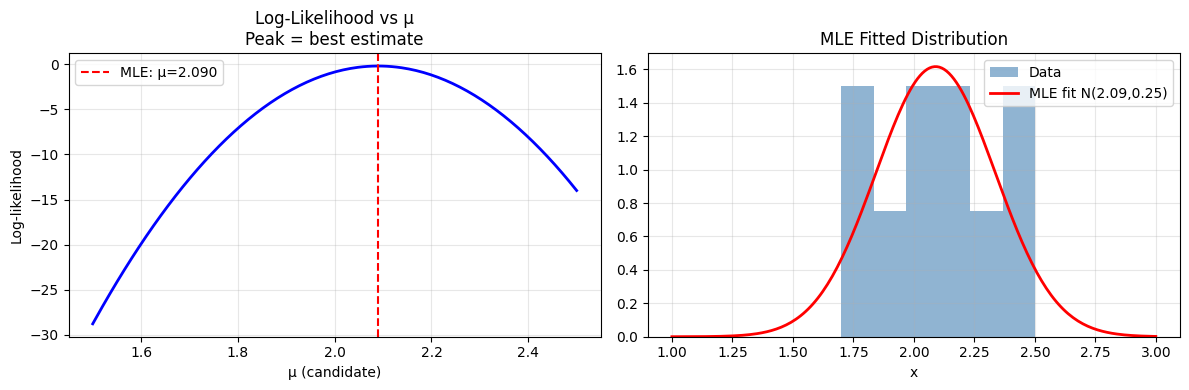


Connection to training:
  Minimizing MSE loss      = MLE with Gaussian noise assumption
  Minimizing cross-entropy = MLE with Bernoulli/Categorical assumption


In [7]:
# MLE for a Gaussian: what μ and σ best explain this data?
data = np.array([2.1, 1.8, 2.5, 2.0, 1.9, 2.3, 2.2, 1.7, 2.4, 2.0])

def log_likelihood(data, mu, sigma):
    # Sum of log P(x | mu, sigma) for all data points
    return np.sum(norm.logpdf(data, mu, sigma))

# Sweep over possible mu values
mus = np.linspace(1.5, 2.5, 200)
ll_values = [log_likelihood(data, mu, np.std(data)) for mu in mus]

# MLE estimates
mu_mle    = np.mean(data)      # MLE for mu = sample mean
sigma_mle = np.std(data)       # MLE for sigma = sample std

print("=== Maximum Likelihood Estimation ===")
print(f"Data: {data}")
print(f"MLE estimate μ    = {mu_mle:.4f}  (= sample mean)")
print(f"MLE estimate σ    = {sigma_mle:.4f}  (= sample std)")
print(f"Max log-likelihood = {log_likelihood(data, mu_mle, sigma_mle):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mus, ll_values, 'b-', lw=2)
axes[0].axvline(mu_mle, color='red', linestyle='--', label=f'MLE: μ={mu_mle:.3f}')
axes[0].set_title('Log-Likelihood vs μ\nPeak = best estimate')
axes[0].set_xlabel('μ (candidate)')
axes[0].set_ylabel('Log-likelihood')
axes[0].legend()

x_range = np.linspace(1, 3, 200)
axes[1].hist(data, bins=6, density=True, alpha=0.6, color='steelblue', label='Data')
axes[1].plot(x_range, norm.pdf(x_range, mu_mle, sigma_mle), 'r-', lw=2, label=f'MLE fit N({mu_mle:.2f},{sigma_mle:.2f})')
axes[1].set_title('MLE Fitted Distribution')
axes[1].set_xlabel('x')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nConnection to training:")
print("  Minimizing MSE loss      = MLE with Gaussian noise assumption")
print("  Minimizing cross-entropy = MLE with Bernoulli/Categorical assumption")

---
## 7. Naive Bayes Classifier

A real ML classifier built directly from Bayes' theorem.

$$P(\text{spam} \mid x_1,...,x_n) \propto P(\text{spam}) \cdot \prod_{i=1}^n P(x_i \mid \text{spam})$$

**"Naive"** = assumes features are independent given the class.  
Rarely true, but works surprisingly well — especially for text classification.

In [8]:
from sklearn.naive_bayes import BernoulliNB

# Naive Bayes spam classifier — from scratch
# Features: [contains 'FREE', contains 'WINNER', contains 'meeting']
X_train = np.array([
    [1,1,0],[1,0,0],[1,1,0],[0,1,0],[1,0,0],  # spam
    [0,0,1],[0,0,0],[0,0,1],[0,1,1],[0,0,0],  # not spam
])
y_train = np.array([1,1,1,1,1,0,0,0,0,0])
features = ['FREE','WINNER','meeting']

# Step 1: Priors
P_spam     = np.mean(y_train == 1)
P_not_spam = np.mean(y_train == 0)

# Step 2: Likelihoods with Laplace smoothing (avoids P=0)
spam_emails     = X_train[y_train == 1]
not_spam_emails = X_train[y_train == 0]
lhood_spam     = (spam_emails.sum(axis=0) + 1) / (len(spam_emails) + 2)
lhood_not_spam = (not_spam_emails.sum(axis=0) + 1) / (len(not_spam_emails) + 2)

print("=== Learned Parameters ===")
print(f"P(spam) = {P_spam:.2f}   P(not spam) = {P_not_spam:.2f}")
print()
for i, word in enumerate(features):
    print(f"P({word:8} | spam)     = {lhood_spam[i]:.3f}")
    print(f"P({word:8} | not spam) = {lhood_not_spam[i]:.3f}")
    print()

# Step 3: Classify new email [FREE=yes, WINNER=yes, meeting=no]
new_email = np.array([1, 1, 0])
log_spam     = np.log(P_spam)
log_not_spam = np.log(P_not_spam)
for i, feat in enumerate(new_email):
    if feat == 1:
        log_spam     += np.log(lhood_spam[i])
        log_not_spam += np.log(lhood_not_spam[i])

pred = 'SPAM' if log_spam > log_not_spam else 'NOT SPAM'
print("=== New Email: FREE=✓  WINNER=✓  meeting=✗ ===")
print(f"log P(spam|email)     = {log_spam:.4f}")
print(f"log P(not spam|email) = {log_not_spam:.4f}")
print(f">>> Prediction: {pred} <<<")

# sklearn version

nb = BernoulliNB()
nb.fit(X_train, y_train)
proba = nb.predict_proba(new_email.reshape(1,-1))[0]
print("\nsklearn BernoulliNB:")
print(f"  P(not spam) = {proba[0]:.4f}")
print(f"  P(spam)     = {proba[1]:.4f}")

=== Learned Parameters ===
P(spam) = 0.50   P(not spam) = 0.50

P(FREE     | spam)     = 0.714
P(FREE     | not spam) = 0.143

P(WINNER   | spam)     = 0.571
P(WINNER   | not spam) = 0.286

P(meeting  | spam)     = 0.143
P(meeting  | not spam) = 0.571

=== New Email: FREE=✓  WINNER=✓  meeting=✗ ===
log P(spam|email)     = -1.5892
log P(not spam|email) = -3.8918
>>> Prediction: SPAM <<<

sklearn BernoulliNB:
  P(not spam) = 0.0476
  P(spam)     = 0.9524


---
## 8. Entropy, KL Divergence & Cross-Entropy

### Entropy — measures uncertainty
$$H(P) = -\sum_i P(x_i) \log P(x_i)$$
- High entropy = high uncertainty (uniform distribution)
- Low entropy = low uncertainty (peaked distribution)

### KL Divergence — how different are two distributions?
$$D_{KL}(P \| Q) = \sum_i P(x_i) \log \frac{P(x_i)}{Q(x_i)}$$
Used in: VAEs, Reinforcement Learning from Human Feedback (RLHF)

### Cross-Entropy Loss — the standard classification loss
$$\mathcal{L} = -\sum_i y_i \log(\hat{y}_i) = H(y) + D_{KL}(y \| \hat{y})$$
Minimizing cross-entropy = making predictions close to true distribution

=== Entropy ===
  Certain      [1.0, 0.0]  →  H = -0.0000 bits
  Mostly sure  [0.9, 0.1]  →  H = 0.4690 bits
  50/50        [0.5, 0.5]  →  H = 1.0000 bits

=== Cross-Entropy Loss ===
  Confident & correct       pred=[0.9, 0.05, 0.05]  Loss=0.1054
  Uncertain                 pred=[0.5, 0.3, 0.2]  Loss=0.6931
  Confident & WRONG         pred=[0.1, 0.8, 0.1]  Loss=2.3026


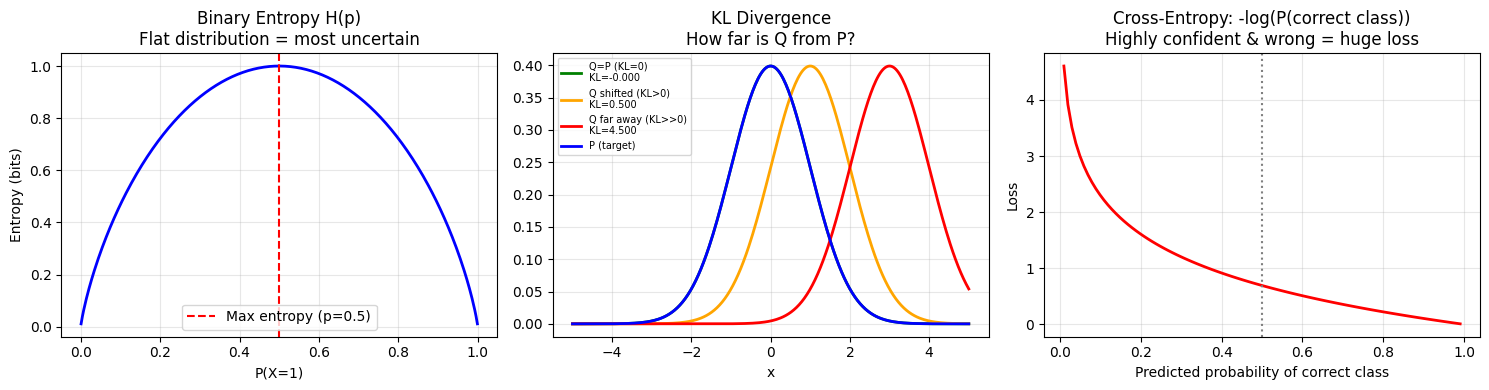

In [9]:
def entropy(p):
    p = np.array(p)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def kl_divergence(p, q):
    p, q = np.array(p), np.array(q)
    return np.sum(p * np.log(p / (q + 1e-10) + 1e-10))

def cross_entropy_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-9, 1-1e-9)
    return -np.sum(y_true * np.log(y_pred))

print("=== Entropy ===")
for dist, name in [([1.0,0.0],'Certain'),([0.9,0.1],'Mostly sure'),([0.5,0.5],'50/50')]:
    print(f"  {name:12} {dist}  →  H = {entropy(dist):.4f} bits")

print("\n=== Cross-Entropy Loss ===")
y_true = np.array([1, 0, 0])   # true class 0
for pred, name in [
    ([0.9, 0.05, 0.05], 'Confident & correct'),
    ([0.5, 0.3,  0.2],  'Uncertain'),
    ([0.1, 0.8,  0.1],  'Confident & WRONG'),
]:
    loss = cross_entropy_loss(y_true, pred)
    print(f"  {name:25} pred={pred}  Loss={loss:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Binary entropy curve
p_vals = np.linspace(0.001, 0.999, 300)
h_vals = [-p*np.log2(p) - (1-p)*np.log2(1-p) for p in p_vals]
axes[0].plot(p_vals, h_vals, 'b-', lw=2)
axes[0].axvline(0.5, color='red', linestyle='--', label='Max entropy (p=0.5)')
axes[0].set_title('Binary Entropy H(p)\nFlat distribution = most uncertain')
axes[0].set_xlabel('P(X=1)')
axes[0].set_ylabel('Entropy (bits)')
axes[0].legend()

# KL divergence: P vs Q
x = np.linspace(-5, 5, 300)
P = norm.pdf(x, 0, 1)     # true distribution
for mu_q, color, label in [(0,'green','Q=P (KL=0)'),(1,'orange','Q shifted (KL>0)'),(3,'red','Q far away (KL>>0)')]:
    Q = norm.pdf(x, mu_q, 1)
    kl = np.trapezoid(P * np.log(P / (Q + 1e-10)), x)
    axes[1].plot(x, norm.pdf(x, mu_q, 1), color=color, lw=2, label=f'{label}\nKL={kl:.3f}')
axes[1].plot(x, P, 'b-', lw=2, label='P (target)')
axes[1].set_title('KL Divergence\nHow far is Q from P?')
axes[1].set_xlabel('x')
axes[1].legend(fontsize=7)

# Cross-entropy loss surface
conf = np.linspace(0.01, 0.99, 100)
losses = [-np.log(c) for c in conf]
axes[2].plot(conf, losses, 'r-', lw=2)
axes[2].axvline(0.5, color='gray', linestyle=':')
axes[2].set_title('Cross-Entropy: -log(P(correct class))\nHighly confident & wrong = huge loss')
axes[2].set_xlabel('Predicted probability of correct class')
axes[2].set_ylabel('Loss')

plt.tight_layout()
plt.show()

---
## 9. Probability in Transformers

Language models output a **probability distribution** over the vocabulary at each step.

$$P(\text{token} \mid \text{context}) = \text{softmax}(\text{logits} / T)$$

- `T=1.0` — standard sampling
- `T<1.0` — **low temperature**: more confident, more deterministic (greedy)
- `T>1.0` — **high temperature**: more random, more creative

**Top-k and Top-p (nucleus) sampling** are also probability operations:
- Top-k: keep only k most likely tokens, renormalize
- Top-p: keep smallest set of tokens whose cumulative probability ≥ p

=== Temperature Effect ===
T=0.5: [('the', '0.589'), ('a', '0.217'), ('cat', '0.080')]
T=1.0: [('the', '0.336'), ('a', '0.204'), ('cat', '0.123')]
T=2.0: [('the', '0.203'), ('a', '0.158'), ('cat', '0.123')]


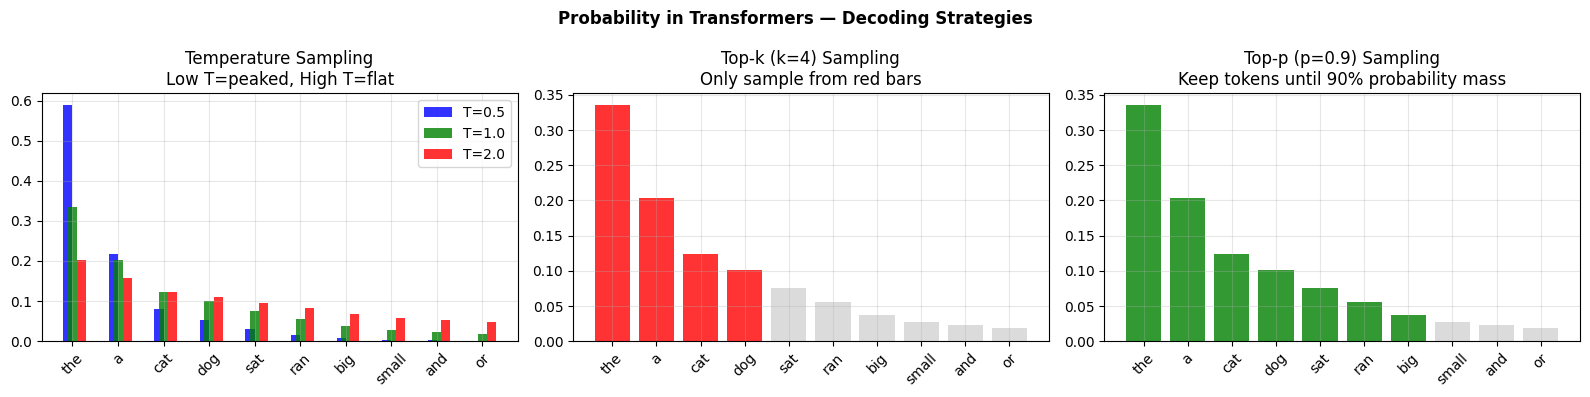

In [10]:
def softmax(logits, temperature=1.0):
    logits = np.array(logits) / temperature
    e = np.exp(logits - logits.max())
    return e / e.sum()

# Vocabulary with logits
vocab = ['the', 'a', 'cat', 'dog', 'sat', 'ran', 'big', 'small', 'and', 'or']
logits = np.array([3.0, 2.5, 2.0, 1.8, 1.5, 1.2, 0.8, 0.5, 0.3, 0.1])

print("=== Temperature Effect ===")
for T in [0.5, 1.0, 2.0]:
    probs = softmax(logits, T)
    top3 = sorted(zip(vocab, probs), key=lambda x: -x[1])[:3]
    print(f"T={T}: {[(w, f'{p:.3f}') for w,p in top3]}")

# Top-k sampling
def top_k_sample(logits, k):
    probs = softmax(logits)
    top_k_idx = np.argsort(probs)[-k:]
    top_k_probs = probs[top_k_idx]
    top_k_probs /= top_k_probs.sum()  # renormalize
    return top_k_idx, top_k_probs

# Top-p (nucleus) sampling
def top_p_sample(logits, p):
    probs = softmax(logits)
    sorted_idx = np.argsort(probs)[::-1]
    cumsum = np.cumsum(probs[sorted_idx])
    cutoff = np.searchsorted(cumsum, p) + 1
    nucleus_idx = sorted_idx[:cutoff]
    nucleus_probs = probs[nucleus_idx]
    nucleus_probs /= nucleus_probs.sum()
    return nucleus_idx, nucleus_probs

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Temperature comparison
for T, color in [(0.5,'blue'),(1.0,'green'),(2.0,'red')]:
    axes[0].bar(np.arange(len(vocab)) + (T-1)*0.2, softmax(logits, T), 0.2,
                label=f'T={T}', alpha=0.8, color=color)
axes[0].set_xticks(range(len(vocab)))
axes[0].set_xticklabels(vocab, rotation=45)
axes[0].set_title('Temperature Sampling\nLow T=peaked, High T=flat')
axes[0].legend()

# Top-k
k_idx, k_probs = top_k_sample(logits, 4)
bar_colors = ['red' if i in k_idx else 'lightgray' for i in range(len(vocab))]
axes[1].bar(range(len(vocab)), softmax(logits), color=bar_colors, alpha=0.8)
axes[1].set_xticks(range(len(vocab)))
axes[1].set_xticklabels(vocab, rotation=45)
axes[1].set_title('Top-k (k=4) Sampling\nOnly sample from red bars')

# Top-p
p_idx, p_probs = top_p_sample(logits, 0.9)
bar_colors2 = ['green' if i in p_idx else 'lightgray' for i in range(len(vocab))]
axes[2].bar(range(len(vocab)), softmax(logits), color=bar_colors2, alpha=0.8)
axes[2].set_xticks(range(len(vocab)))
axes[2].set_xticklabels(vocab, rotation=45)
axes[2].set_title('Top-p (p=0.9) Sampling\nKeep tokens until 90% probability mass')

plt.suptitle('Probability in Transformers — Decoding Strategies', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Probability in Generative AI

### VAE (Variational Autoencoder)
Instead of encoding to a single point, VAE encodes to a **probability distribution**:

```
Encoder: x → μ, σ        (distribution parameters)
Sample:  z ~ N(μ, σ²)    (sample from the distribution)
Decoder: z → x̂           (reconstruct)
```

**VAE Loss = Reconstruction loss + KL Divergence**
$$\mathcal{L} = \underbrace{||x - \hat{x}||^2}_{\text{reconstruction}} + \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{regularize latent space}}$$

### Diffusion Models
The model learns to **reverse** a gradual noising process.  
At each step, it predicts the noise `ε` that was added:  
$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \sigma_t^2)$$

=== VAE Loss ===
Reconstruction loss:  1.0796  (how well did we reconstruct x?)
KL divergence:        1.1113     (how far is q(z|x) from N(0,1)?)
Total VAE loss:       1.1907

Reparameterization trick:
  mu      = [ 0.5 -0.3  0.1] ...
  sigma   = [0.779 1.105 0.861] ...
  epsilon = random N(0,1) — gradient STOPS here
  z       = mu + sigma*eps — gradient flows through mu and sigma


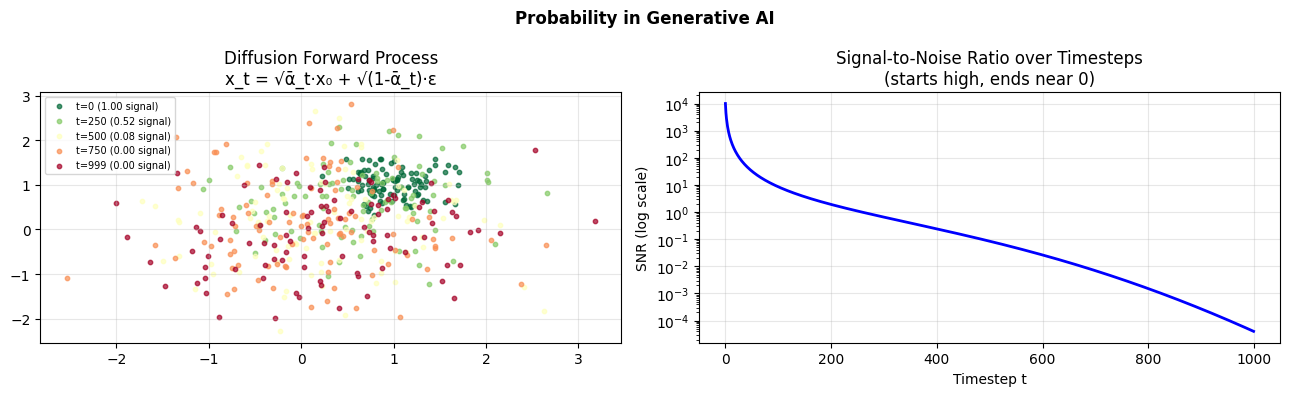

In [11]:
# VAE loss decomposition
def reconstruction_loss(x, x_hat):
    return np.mean((x - x_hat)**2)

def kl_loss(mu, log_var):
    return -0.5 * np.sum(1 + log_var - mu**2 - np.exp(log_var))

def reparameterize(mu, log_var):
    eps = np.random.randn(*mu.shape)       # random but NOT differentiable
    return mu + np.exp(0.5 * log_var) * eps  # gradient flows through mu, log_var

np.random.seed(0)
x = np.random.randn(10)
mu      = np.array([0.5, -0.3, 0.1, 0.8, -0.2, 0.6, -0.1, 0.3, -0.5, 0.4])
log_var = np.array([-0.5, 0.2, -0.3, 0.1, -0.1, -0.4, 0.3, -0.2, 0.0, -0.1])

z = reparameterize(mu, log_var)
x_hat = z * 0.9 + 0.05   # simplified decoder

recon = reconstruction_loss(x, x_hat)
kl    = kl_loss(mu, log_var)
total = recon + 0.1 * kl

print("=== VAE Loss ===")
print(f"Reconstruction loss:  {recon:.4f}  (how well did we reconstruct x?)")
print(f"KL divergence:        {kl:.4f}     (how far is q(z|x) from N(0,1)?)")
print(f"Total VAE loss:       {total:.4f}")
print()
print("Reparameterization trick:")
print(f"  mu      = {mu[:3].round(3)} ...")
print(f"  sigma   = {np.exp(0.5*log_var[:3]).round(3)} ...")
print("  epsilon = random N(0,1) — gradient STOPS here")
print("  z       = mu + sigma*eps — gradient flows through mu and sigma")

# Diffusion forward process visualization
T = 1000
betas = np.linspace(1e-4, 0.02, T)
alpha_bars = np.cumprod(1 - betas)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Signal vs noise over time
x0_signal = np.random.randn(100, 2) * 0.3 + [1, 1]
cmap = plt.colormaps["RdYlGn"]
for t_idx, color in zip(
    [0, 250, 500, 750, 999],
    cmap(np.linspace(1, 0, 5))
):
    ab = alpha_bars[t_idx]
    x_t = np.sqrt(ab) * x0_signal + np.sqrt(1-ab) * np.random.randn(*x0_signal.shape)
    axes[0].scatter(x_t[:,0], x_t[:,1], s=10, color=color, alpha=0.7,
                    label=f't={t_idx} ({ab:.2f} signal)')
axes[0].set_title('Diffusion Forward Process\nx_t = √ᾱ_t·x₀ + √(1-ᾱ_t)·ε')
axes[0].legend(fontsize=7)

# Signal-to-noise ratio
snr = alpha_bars / (1 - alpha_bars)
axes[1].plot(snr, 'b-', lw=2)
axes[1].set_yscale('log')
axes[1].set_title('Signal-to-Noise Ratio over Timesteps\n(starts high, ends near 0)')
axes[1].set_xlabel('Timestep t')
axes[1].set_ylabel('SNR (log scale)')

plt.suptitle('Probability in Generative AI', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary — Probability Across the Stack

```
Classic ML
  └── Conditional probability             → Naive Bayes classifier
  └── MLE                                 → How MSE and cross-entropy loss are derived
  └── Gaussian distribution               → Linear regression noise assumption

Deep Learning
  └── Bernoulli distribution              → Binary classification (sigmoid output)
  └── Categorical distribution            → Multi-class (softmax output)
  └── Cross-entropy loss                  → Minimizing = maximizing log-likelihood
  └── KL divergence                       → Regularization term in VAEs

Transformers
  └── Softmax                             → Converts logits to probability distribution
  └── Temperature                         → Controls sharpness of distribution
  └── Top-k / Top-p sampling              → Probability-based decoding

Generative AI
  └── VAE: q(z|x) ~ N(μ,σ²)             → Latent space as a distribution
  └── Reparameterization trick            → Makes sampling differentiable
  └── Diffusion: p_θ(x_{t-1}|x_t)       → Learned reverse of noising process
  └── RLHF reward model                   → P(human prefers A over B)
```

| Concept | Formula | Where |
|---|---|---|
| Conditional | `P(A\|B) = P(A,B)/P(B)` | Every classifier |
| Bayes | `P(A\|B) ∝ P(B\|A)·P(A)` | Inference, Naive Bayes |
| Gaussian | `N(μ,σ²)` | Regression, VAE latent, diffusion |
| MLE | `argmax Σ log P(xᵢ\|θ)` | All model training |
| Cross-entropy | `-Σ y log ŷ` | Classification loss |
| KL divergence | `Σ P log(P/Q)` | VAE, RLHF |
| Softmax | `exp(z)/Σexp(z)` | Classifier output, attention |
| Temperature | `softmax(z/T)` | LLM generation |

### What to learn next
- **Statistics notebook** → hypothesis testing, confidence intervals, A/B testing for ML
- **Logistic regression** → Bernoulli + MLE applied to binary classification
- **VAE from scratch** → putting all of this together in a real generative model